# 06 — Analysis and Plots

Build everything that goes into the blog plus a few diagnostics.

## The four charts that go into the blog

Each one is built to carry a single piece of the story. The narrative arc:

| File | Story it tells | Why it earns its space |
|---|---|---|
| `chart_1_assessment_mix.png`         | **How** each Exeter UG department divides 100% of its marks between coursework, written exams and practicals. | Sets up the variation. The reader can see at a glance that BEE / MTH / PHY are the only depts where exams still drive the mark, and that everything else lives in the 80%+ coursework band. |
| `chart_2_trends.png`                 | **Has it changed?** Mean coursework share over time, one line per faculty, 2019/20 → 2024/25. | Shows the covid dip in ESE and the steady drift towards coursework everywhere. Time-series → lines (per the rubric). |
| `chart_3_feature_importance.png`     | **What predicts NSS Assessment & Feedback satisfaction?** Random forest feature importance, ranked. | The empirical pivot. Top two features (assessment diversity + count of summative items) tower over the assessment-mix variables: variety + rhythm > exam-vs-coursework. |
| `chart_4_pred_vs_actual.png`         | **How well can we predict satisfaction at all?** Cross-validated predicted vs actual NSS A&F. | Validity check. R² ≈ 0.45 with no information about lecturer quality is more than I expected. The outliers (NSC above the line, Law below) are where culture lives. |

## Inputs

All from `data/processed2/`, written by notebooks 03–05:
- `merged_subject.csv`  — subject × year, used by chart 1's annotations and the summary table
- `merged_dept.csv`     — dept × year, used by the model (charts 3 & 4)
- `dept_year_summary.csv` — dept × year (no NSS), used by charts 1 and 2
- `modules_clean.csv`   — module × year, used by the diagnostics section only
- `nss_exeter_taughtat_wide.csv` — used by the optional R-vs-T diagnostic

## Outputs

Four blog-bound charts and a summary table:
- `output2/figures/chart_1_assessment_mix.png`
- `output2/figures/chart_2_trends.png`
- `output2/figures/chart_3_feature_importance.png`
- `output2/figures/chart_4_pred_vs_actual.png`
- `data/processed2/blog_summary_table.csv`

The diagnostics section at the bottom optionally writes a few extra charts (`diag_*.png`) that are useful but didn't make the blog cut.

## 1. Setup

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.metrics import r2_score, mean_absolute_error
import statsmodels.api as sm

HERE = Path.cwd()
PROJECT_ROOT = HERE if (HERE / 'data' / 'raw').exists() else HERE.parent
PROCESSED = PROJECT_ROOT / 'data' / 'processed2'
FIG_DIR   = PROJECT_ROOT / 'output2' / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style='whitegrid', context='talk')
FACULTY_PALETTE = {'ESE': '#1f77b4', 'HLS': '#2ca02c', 'HASS': '#d62728', 'Unknown': '#7f7f7f'}
FIG_DPI = 150

merged_subject = pd.read_csv(PROCESSED / 'merged_subject.csv')
merged_dept    = pd.read_csv(PROCESSED / 'merged_dept.csv')
modules        = pd.read_csv(PROCESSED / 'modules_clean.csv')
dept_year      = pd.read_csv(PROCESSED / 'dept_year_summary.csv')

# Theme columns ONLY — exclude both identifier columns 'nss_year' and 'nss_subject'.
# Both start with 'nss_' so a naive prefix filter would pick them up.
nss_cols = [c for c in merged_subject.columns
            if c.startswith('nss_') and c not in ('nss_year', 'nss_subject')]

TARGET = 'nss_assessment_feedback'

print(f'merged_subject: {len(merged_subject):,} rows')
print(f'merged_dept   : {len(merged_dept):,} rows')
print(f'modules       : {len(modules):,} rows')
print(f'NSS theme cols: {nss_cols}')

merged_subject: 105 rows
merged_dept   : 136 rows
modules       : 5,626 rows
NSS theme cols: ['nss_academic_support', 'nss_assessment_feedback', 'nss_free_expression', 'nss_learning_opps', 'nss_learning_resources', 'nss_organisation', 'nss_student_voice', 'nss_teaching']


## 2. BLOG CHART 1 — Assessment mix by department

**Story it tells:** every Exeter UG department on one chart, with their share of coursework / written exam / practical assessment, sorted from least coursework to most.

**Why it works:** the reader can immediately see who's exam-heavy (BEE, MTH, PHY at the bottom) vs coursework-heavy (Education, sociology variants at the top), and that the middle is unusually empty. Categorical data → bar chart, per the project rubric.

**Caption draft:** *Each bar is one Exeter undergraduate department in 2024/25. Blue is coursework, orange is written exams, green is practicals. Bars sum to 100%.*

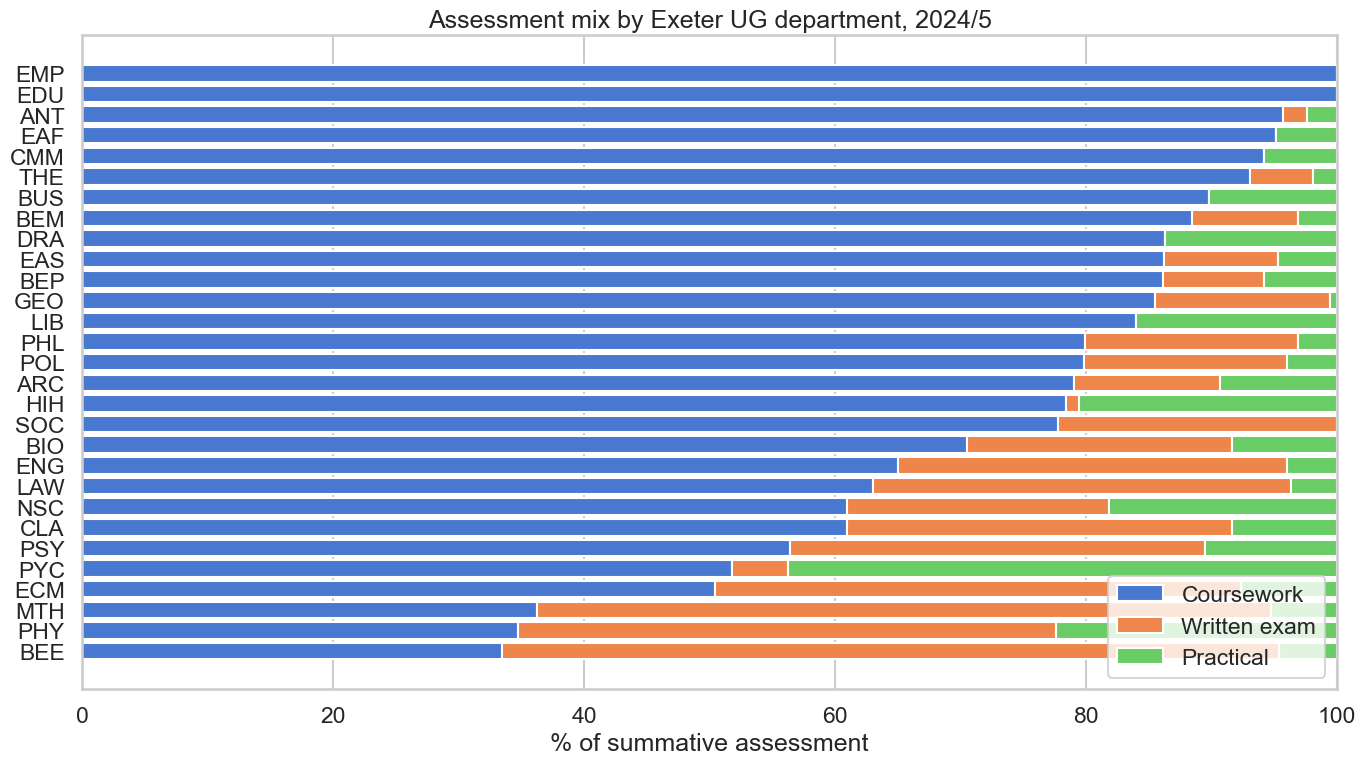

Saved: chart_1_assessment_mix.png  (29 departments)


In [3]:
latest_year = dept_year['academic_year'].max()
latest = (dept_year[dept_year['academic_year'] == latest_year]
          .dropna(subset=['mean_coursework_pct'])
          .sort_values('mean_coursework_pct', ascending=False))

fig, ax = plt.subplots(figsize=(14, 8))
y = np.arange(len(latest))
ax.barh(y, latest['mean_coursework_pct'],   color='#4878d0', label='Coursework')
ax.barh(y, latest['mean_written_exam_pct'], left=latest['mean_coursework_pct'],
        color='#ee854a', label='Written exam')
ax.barh(y, latest['mean_practical_pct'],
        left=latest['mean_coursework_pct'] + latest['mean_written_exam_pct'],
        color='#6acc64', label='Practical')
ax.set_yticks(y); ax.set_yticklabels(latest['dept_code'])
ax.invert_yaxis(); ax.set_xlim(0, 100)
ax.set_xlabel('% of summative assessment')
ax.set_title(f'Assessment mix by Exeter UG department, {latest_year}')
ax.legend(loc='lower right', frameon=True)
plt.tight_layout()
plt.savefig(FIG_DIR / 'chart_1_assessment_mix.png', dpi=FIG_DPI, bbox_inches='tight')
plt.show()

print(f'Saved: chart_1_assessment_mix.png  ({len(latest)} departments)')

## 3. BLOG CHART 2 — Coursework trend over time, by faculty

**Story it tells:** the share of marks awarded for coursework, averaged across each faculty's modules, for every academic year from 2019/20 to 2024/25.

**Why it works:** time series → lines (per the rubric). The covid dip in ESE jumps off the page, and the steady upward drift in HASS shows the move was already underway. The legend reports `n` departments per faculty so the reader knows the lines aren't built from one or two outliers.

**Caption draft:** *Mean coursework share across all UG modules in each faculty. ESE is environment, science and economy; HASS is humanities, arts and social sciences; HLS is health and life sciences.*

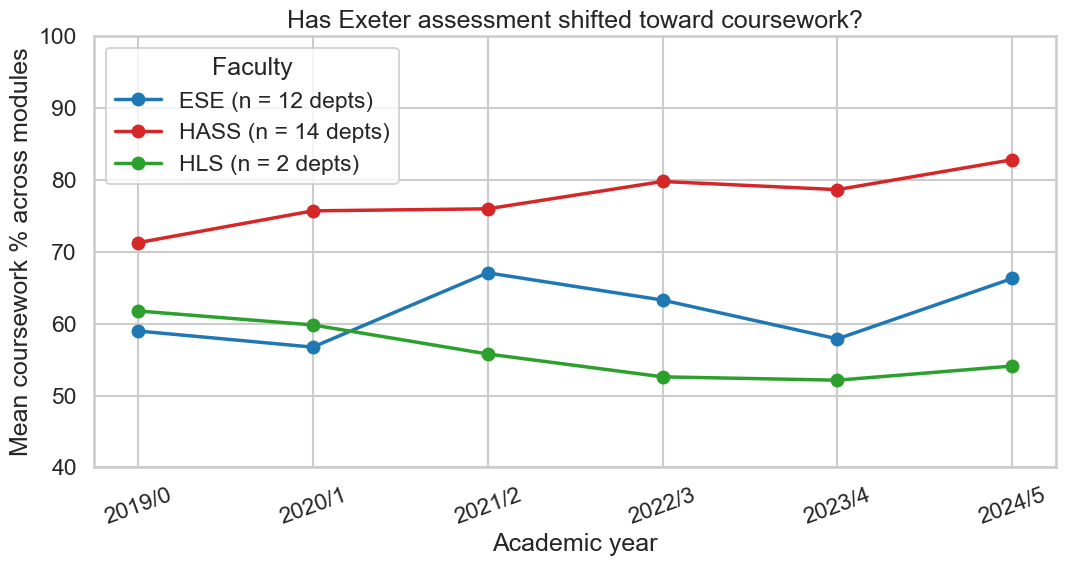

Saved: chart_2_trends.png


In [5]:
trend = (
    dept_year.dropna(subset=['mean_coursework_pct'])
             .groupby(['academic_year', 'faculty'], as_index=False)
             .agg(coursework=('mean_coursework_pct', 'mean'),
                  n_depts=('dept_code', 'nunique'))
)

fig, ax = plt.subplots(figsize=(11, 6))
for faculty, sub in trend.groupby('faculty'):
    if faculty == 'Unknown':
        continue
    sub = sub.sort_values('academic_year')
    ax.plot(sub['academic_year'], sub['coursework'],
            marker='o', linewidth=2.5, markersize=9,
            color=FACULTY_PALETTE.get(faculty, '#888'),
            label=f'{faculty} (n = {sub["n_depts"].max()} depts)')

ax.set_ylabel('Mean coursework % across modules')
ax.set_xlabel('Academic year')
ax.set_title('Has Exeter assessment shifted toward coursework?')
ax.legend(title='Faculty', frameon=True)
ax.set_ylim(40, 100)
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(FIG_DIR / 'chart_2_trends.png', dpi=FIG_DPI, bbox_inches='tight')
plt.show()

print('Saved: chart_2_trends.png')

## 4. Fit the model

Before charts 3 and 4, we fit one random forest on the pooled (dept × year) dataset. Charts 3 and 4 then read from the same fit, so they tell a coherent story rather than two slightly-different models.

**What's being modelled:** the dept's NSS *Assessment & Feedback* positivity score, regressed on eight module-design features. Cross-validated with 5-fold CV; the CV R² is the only measure of fit we trust given the small sample.

In [7]:
FEATURES = [
    'mean_coursework_pct', 'mean_written_exam_pct', 'mean_practical_pct',
    'mean_class_size',     'mean_scheduled_hours',  'mean_contact_ratio',
    'mean_assess_diversity', 'mean_n_summative_items',
]

model_df = merged_dept.dropna(subset=FEATURES + [TARGET]).copy().reset_index(drop=True)
print(f'Model dataset: {len(model_df)} rows × {len(FEATURES)} features\n')

X = model_df[FEATURES].values
y = model_df[TARGET].values

rf = RandomForestRegressor(n_estimators=500, min_samples_leaf=2, random_state=42)
cv = KFold(n_splits=5, shuffle=True, random_state=42)
y_pred_rf = cross_val_predict(rf, X, y, cv=cv)
rf.fit(X, y)
rf_r2  = r2_score(y, y_pred_rf)
rf_mae = mean_absolute_error(y, y_pred_rf)

ols = sm.OLS(y, sm.add_constant(model_df[FEATURES])).fit()

print(f'Random forest (5-fold CV):  R² = {rf_r2:+.3f}  MAE = {rf_mae:.2f} ppt')
print(f'OLS in-sample:               R² = {ols.rsquared:+.3f}  adj-R² = {ols.rsquared_adj:+.3f}')
print()
print(ols.summary().tables[1])

Model dataset: 72 rows × 8 features

Random forest (5-fold CV):  R² = +0.455  MAE = 2.53 ppt
OLS in-sample:               R² = +0.493  adj-R² = +0.438

                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                      0.0194      0.002     10.530      0.000       0.016       0.023
mean_coursework_pct        0.7066      0.038     18.508      0.000       0.630       0.783
mean_written_exam_pct      0.6540      0.074      8.849      0.000       0.506       0.802
mean_practical_pct         0.5816      0.099      5.890      0.000       0.384       0.779
mean_class_size            0.0118      0.013      0.889      0.377      -0.015       0.038
mean_scheduled_hours      -0.0097      0.043     -0.227      0.821      -0.095       0.075
mean_contact_ratio        -5.7198      6.606     -0.866      0.390     -18.916       7.477
mean_assess_diversity     -2.

## 5. BLOG CHART 3 — Random-forest feature importance

**Story it tells:** of the eight module-design variables we measured, which ones explain the most variation in NSS Assessment & Feedback scores between departments?

**Why it works:** this is the empirical pivot of the blog. The two top features — *assessment diversity* and *number of summative items* — collectively account for over half the model's predictive power. The exam-vs-coursework variables sit at the bottom. The headline becomes "variety good, monoculture bad," not "more coursework, more happy."

**Caption draft:** *Higher bars mean a feature explains more of the variation in NSS Assessment & Feedback scores between departments. Random forest, 500 trees, 5-fold cross-validation, n = {n_rows} (dept × NSS year) rows.*

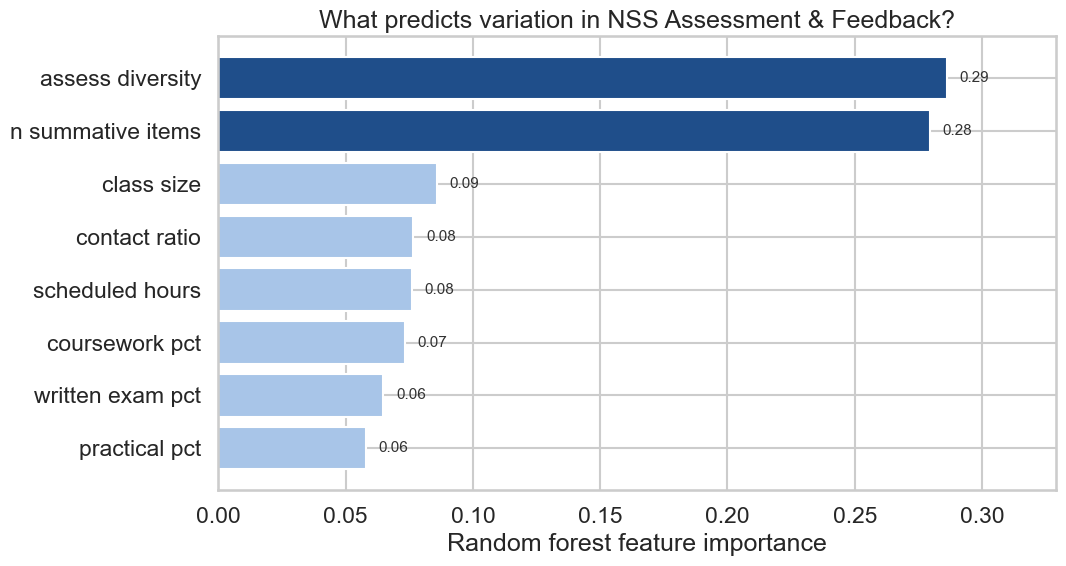

Saved: chart_3_feature_importance.png
Top two features account for 57% of total importance.


In [9]:
imp = pd.Series(rf.feature_importances_, index=FEATURES).sort_values()
labels = imp.index.str.replace('mean_', '').str.replace('_', ' ')

# Highlight the top 2 in a darker shade.
colors = ['#a8c5e8'] * len(imp)
colors[-1] = '#1f4e8a'
colors[-2] = '#1f4e8a'

fig, ax = plt.subplots(figsize=(11, 6))
ax.barh(labels, imp.values, color=colors)
ax.set_xlabel('Random forest feature importance')
ax.set_title('What predicts variation in NSS Assessment & Feedback?')
for i, v in enumerate(imp.values):
    ax.text(v + 0.005, i, f'{v:.2f}', va='center', fontsize=11, color='#333')
ax.set_xlim(0, max(imp.values) * 1.15)
plt.tight_layout()
plt.savefig(FIG_DIR / 'chart_3_feature_importance.png', dpi=FIG_DPI, bbox_inches='tight')
plt.show()

top_two_share = imp.values[-2:].sum()
print(f'Saved: chart_3_feature_importance.png')
print(f'Top two features account for {top_two_share:.0%} of total importance.')

## 6. BLOG CHART 4 — Predicted vs actual NSS scores (cross-validated)

**Story it tells:** for each (dept × NSS year) row, the random forest's cross-validated prediction (x-axis) vs the actual NSS Assessment & Feedback score (y-axis). The dashed line is perfect prediction; points further from it are where the model misses.

**Why it works:** this answers the blog's natural follow-up — "OK, but how well can the model actually do this?" CV R² ≈ 0.45 sits visibly in the title; the spread around the diagonal makes the uncertainty tangible. Outliers (those above or below the line by more than the top-15% absolute residual) get labelled, because that's where the interesting stories are.

**Caption draft:** *Each dot is one Exeter department in one NSS year. The dashed line is perfect prediction. The model uses module structure only — no information about lecturer quality, individual seminar sizes, or feedback turnaround.*

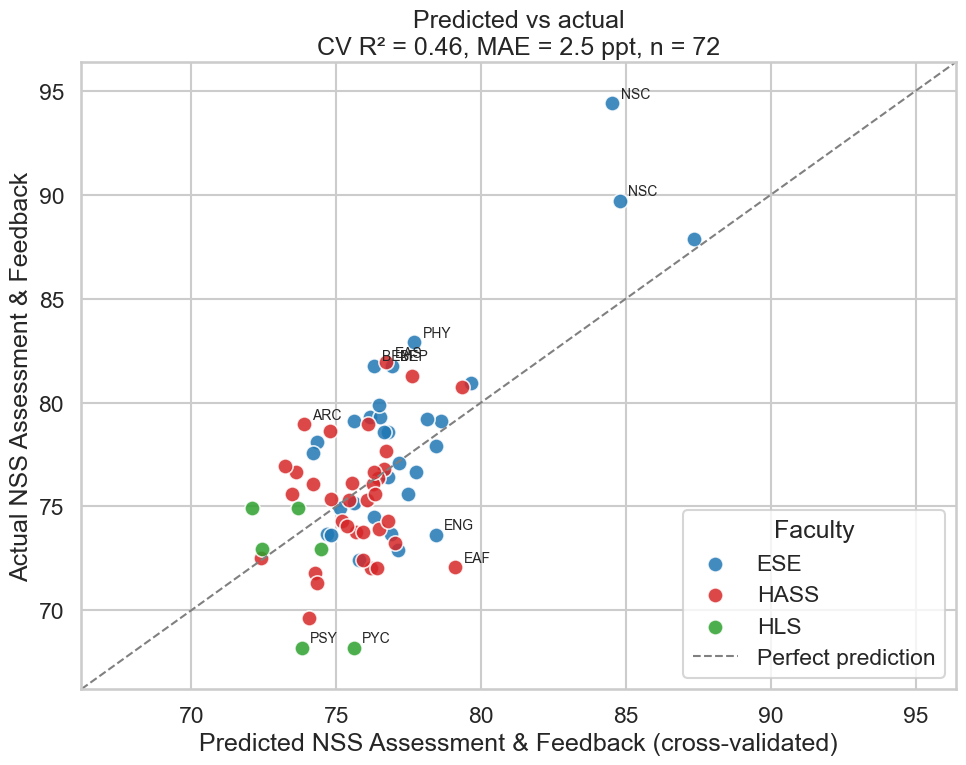

Saved: chart_4_pred_vs_actual.png


In [11]:
fig, ax = plt.subplots(figsize=(10, 8))
for faculty, sub in model_df.groupby('faculty'):
    rows = sub.index.values
    ax.scatter(y_pred_rf[rows], y[rows],
               s=120, alpha=0.85, edgecolor='white', linewidth=1.2,
               color=FACULTY_PALETTE.get(faculty, '#888'),
               label=faculty)

lims = [min(y.min(), y_pred_rf.min()) - 2, max(y.max(), y_pred_rf.max()) + 2]
ax.plot(lims, lims, '--', color='gray', linewidth=1.5, label='Perfect prediction')
ax.set_xlim(lims); ax.set_ylim(lims)

# Label the most distant points so the reader can see where the model misses.
residuals = y - y_pred_rf
threshold = np.quantile(np.abs(residuals), 0.85)
for i in range(len(model_df)):
    if abs(residuals[i]) >= threshold:
        ax.annotate(model_df.iloc[i]['dept_code'],
                    (y_pred_rf[i], y[i]),
                    xytext=(6, 4), textcoords='offset points', fontsize=10)

ax.set_xlabel('Predicted NSS Assessment & Feedback (cross-validated)')
ax.set_ylabel('Actual NSS Assessment & Feedback')
ax.set_title(f'Predicted vs actual\nCV R\u00b2 = {rf_r2:.2f}, MAE = {rf_mae:.1f} ppt, n = {len(model_df)}')
ax.legend(title='Faculty', frameon=True, loc='lower right')
plt.tight_layout()
plt.savefig(FIG_DIR / 'chart_4_pred_vs_actual.png', dpi=FIG_DPI, bbox_inches='tight')
plt.show()

print('Saved: chart_4_pred_vs_actual.png')

## 7. Summary table for the blog

Compact one-row-per-subject table for the latest NSS year (2025), sorted by Assessment & Feedback positivity. Useful for the methods section or as a small inline `<table>` in the HTML.

In [13]:
latest_nss_year = int(merged_subject['nss_year'].dropna().max())
summary = merged_subject[merged_subject['nss_year'] == latest_nss_year].copy()
summary = summary.dropna(subset=['mean_coursework_pct'])

def label_assess(row):
    if row['mean_coursework_pct'] > 70: return 'Coursework-heavy'
    if row['mean_written_exam_pct'] > 50: return 'Exam-heavy'
    return 'Mixed'

summary['assessment_style'] = summary.apply(label_assess, axis=1)

cols = (['nss_subject', 'faculty', 'mean_coursework_pct', 'mean_written_exam_pct',
         'mean_class_size', 'assessment_style'] + nss_cols)
cols = [c for c in cols if c in summary.columns]

out = summary[cols].sort_values(TARGET, ascending=False, na_position='last')
out.to_csv(PROCESSED / 'blog_summary_table.csv', index=False)
print(f'Wrote: blog_summary_table.csv  ({len(out)} subjects)')
out[[c for c in ['nss_subject','faculty','mean_coursework_pct','assessment_style',TARGET] if c in out.columns]].head(20)

Wrote: blog_summary_table.csv  (19 subjects)


,nss_subject,faculty,mean_coursework_pct,assessment_style,nss_assessment_feedback
37,"General, applied and forensic sciences",ESE,60.960000,Mixed,94.394776
8,Business and management,ESE,87.683044,Coursework-heavy,81.781000
67,Mathematical sciences,ESE,36.276596,Exam-heavy,80.927656
43,"Geography, earth and environmental studies",ESE,85.479452,Coursework-heavy,79.873923
25,Engineering,ESE,63.206937,Mixed,79.291642
86,Physics and astronomy,ESE,34.711538,Mixed,79.203187
19,Economics,ESE,33.476190,Exam-heavy,78.112928
55,Languages and area studies,HASS,60.941176,Mixed,76.799185
14,Computing,ESE,50.476190,Mixed,76.647310
77,Performing arts,HASS,86.333333,Coursework-heavy,76.139891


---

## Files for the blog

Four PNGs in `output2/figures/` and one CSV in `data/processed2/`:

1. `chart_1_assessment_mix.png`
2. `chart_2_trends.png`
3. `chart_3_feature_importance.png`
4. `chart_4_pred_vs_actual.png`
5. `blog_summary_table.csv`

Anything below this line is a diagnostic — useful when writing the methods section, but not in the four blog charts.

---

## 8. Diagnostics  *(not in the blog)*

These four charts were live in the v2 draft but didn't make the final cut. They are useful when writing the Methods section or when you want to cite a robustness / coverage check, but the blog argument doesn't need them.

- `diag_a_coursework_vs_satisfaction.png` — the null-result scatter that sets up chart 3's pivot
- `diag_b_nss_theme_heatmap.png`         — every NSS theme × every subject, one big heatmap
- `diag_c_per_theme_importance.png`      — per-theme random-forest feature importance heatmap
- `diag_d_robustness_r_vs_t.png`         — registered vs taught-at NSS scores (identical at Exeter)

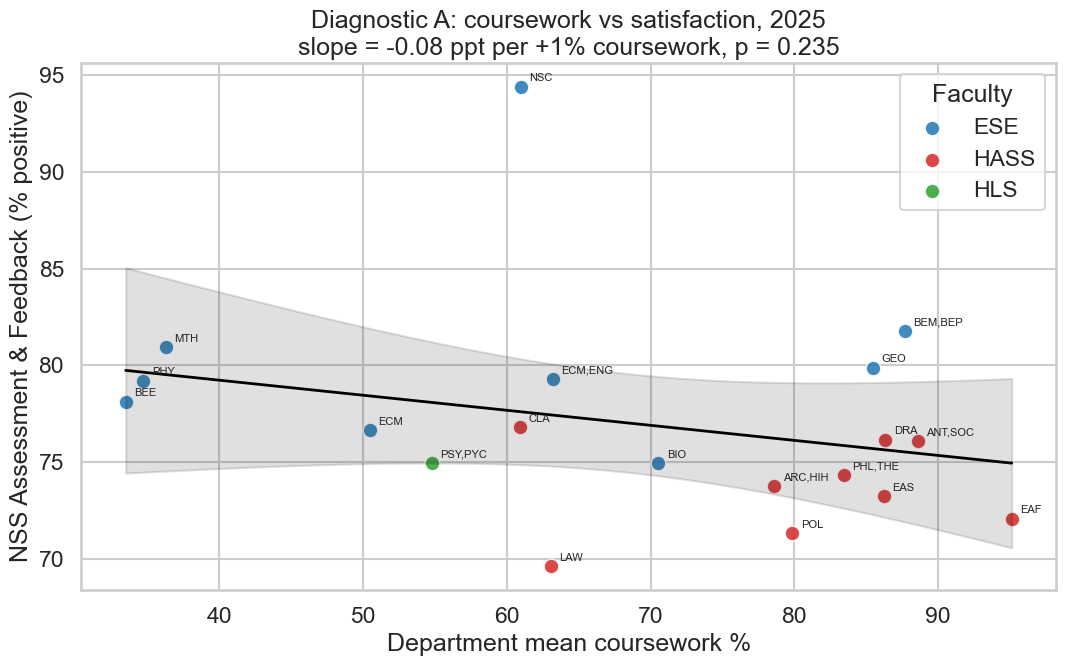

In [15]:
# Diagnostic A — coursework % vs satisfaction (the null result that sets up chart 3).
df3 = (merged_subject[merged_subject['nss_year'] == latest_nss_year]
       .dropna(subset=['mean_coursework_pct', TARGET]))
x = df3['mean_coursework_pct'].values
y2 = df3[TARGET].values
ols_d = sm.OLS(y2, sm.add_constant(x)).fit()
x_grid = np.linspace(x.min(), x.max(), 100)
pred = ols_d.get_prediction(sm.add_constant(x_grid)).summary_frame(alpha=0.05)

fig, ax = plt.subplots(figsize=(11, 7))
for faculty, sub in df3.groupby('faculty'):
    ax.scatter(sub['mean_coursework_pct'], sub[TARGET], s=110, alpha=0.85,
               edgecolor='white', linewidth=1, color=FACULTY_PALETTE.get(faculty, '#888'),
               label=faculty)
ax.plot(x_grid, pred['mean'], color='black', linewidth=2)
ax.fill_between(x_grid, pred['mean_ci_lower'], pred['mean_ci_upper'], color='black', alpha=0.12)
for _, row in df3.iterrows():
    ax.annotate(row['dept_codes_included'],
                (row['mean_coursework_pct'], row[TARGET]),
                xytext=(6, 4), textcoords='offset points', fontsize=8)
ax.set_xlabel('Department mean coursework %')
ax.set_ylabel('NSS Assessment & Feedback (% positive)')
ax.set_title(f'Diagnostic A: coursework vs satisfaction, {latest_nss_year}\n'
             f'slope = {ols_d.params[1]:+.2f} ppt per +1% coursework, p = {ols_d.pvalues[1]:.3f}')
ax.legend(title='Faculty', frameon=True)
plt.tight_layout()
plt.savefig(FIG_DIR / 'diag_a_coursework_vs_satisfaction.png', dpi=FIG_DPI, bbox_inches='tight')
plt.show()

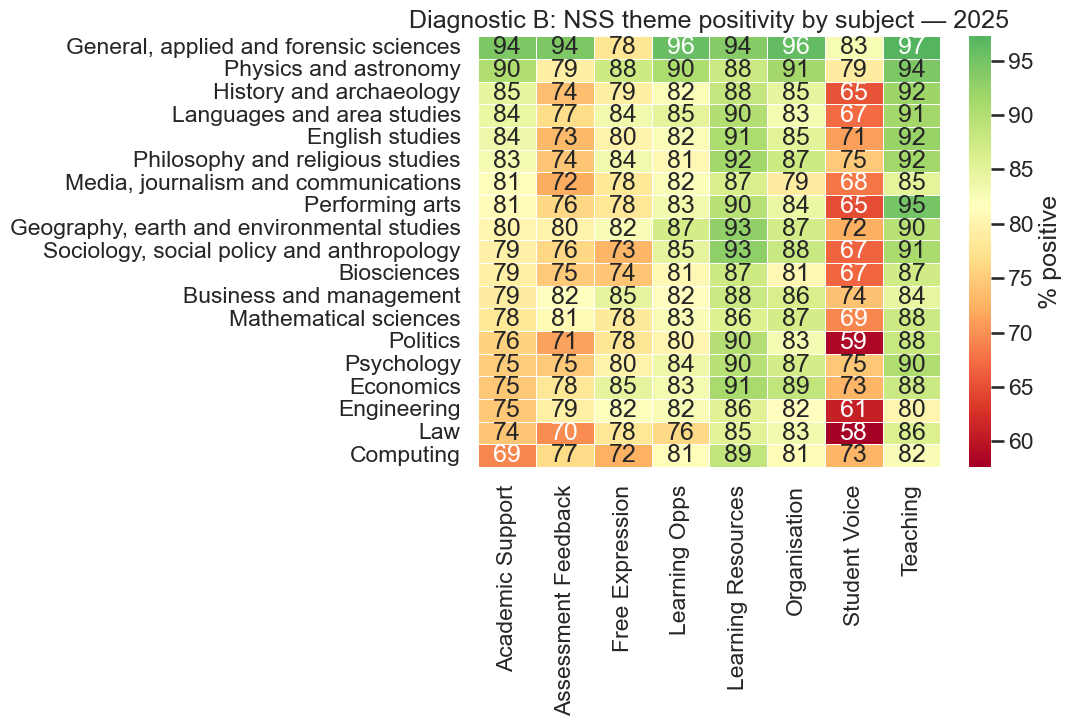

In [17]:
# Diagnostic B — full NSS theme heatmap by subject for the latest year.
h = (merged_subject[merged_subject['nss_year'] == latest_nss_year]
     .dropna(subset=nss_cols, how='all')
     .set_index('nss_subject')[nss_cols])
h.columns = [c.replace('nss_', '').replace('_', ' ').title() for c in h.columns]
h = h.sort_values(h.columns[0], ascending=False)

fig, ax = plt.subplots(figsize=(11, max(6, 0.4 * len(h))))
sns.heatmap(h, annot=True, fmt='.0f', cmap='RdYlGn',
            center=h.values.mean() if h.size else 70,
            cbar_kws={'label': '% positive'}, ax=ax,
            linewidths=0.4, linecolor='white')
ax.set_title(f'Diagnostic B: NSS theme positivity by subject — {latest_nss_year}')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig(FIG_DIR / 'diag_b_nss_theme_heatmap.png', dpi=FIG_DPI, bbox_inches='tight')
plt.show()

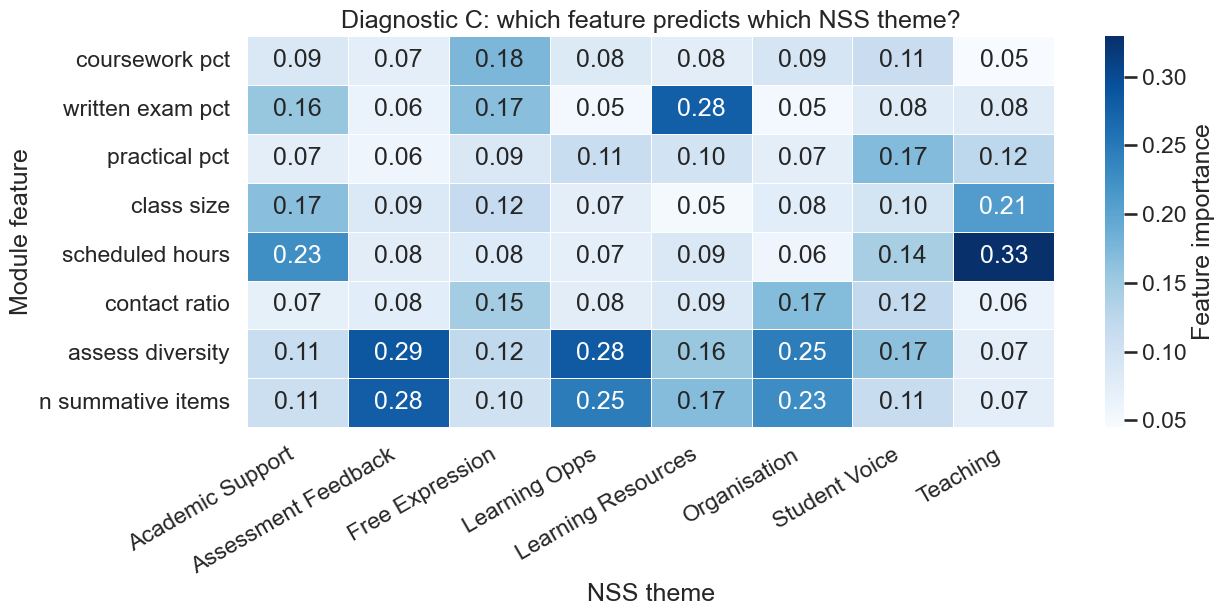


Cross-validated R² per theme:
  nss_academic_support                +0.454
  nss_assessment_feedback             +0.455
  nss_free_expression                 -0.205
  nss_learning_opps                   +0.281
  nss_learning_resources              +0.116
  nss_organisation                    +0.388
  nss_student_voice                   +0.185
  nss_teaching                        +0.481


In [19]:
# Diagnostic C — per-theme feature importance (a separate RF for each of the 8 themes).
imp_table = pd.DataFrame(index=FEATURES, columns=nss_cols, dtype=float)
cv_r2 = {}
for theme in nss_cols:
    df_t = merged_dept.dropna(subset=FEATURES + [theme])
    if len(df_t) < 20:
        continue
    Xt, yt = df_t[FEATURES].values, df_t[theme].values
    rf_t = RandomForestRegressor(n_estimators=500, min_samples_leaf=2, random_state=42)
    yp = cross_val_predict(rf_t, Xt, yt, cv=KFold(5, shuffle=True, random_state=42))
    rf_t.fit(Xt, yt)
    imp_table[theme] = rf_t.feature_importances_
    cv_r2[theme] = r2_score(yt, yp)

imp_table.columns = [c.replace('nss_', '').replace('_', ' ').title() for c in imp_table.columns]
imp_table.index   = imp_table.index.str.replace('mean_', '').str.replace('_', ' ')

fig, ax = plt.subplots(figsize=(13, 6.5))
sns.heatmap(imp_table.astype(float), annot=True, fmt='.2f',
            cmap='Blues', cbar_kws={'label': 'Feature importance'},
            linewidths=0.4, linecolor='white', ax=ax)
ax.set_title('Diagnostic C: which feature predicts which NSS theme?')
ax.set_xlabel('NSS theme'); ax.set_ylabel('Module feature')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig(FIG_DIR / 'diag_c_per_theme_importance.png', dpi=FIG_DPI, bbox_inches='tight')
plt.show()

print('\nCross-validated R² per theme:')
for k, v in cv_r2.items():
    print(f'  {k:35s} {v:+.3f}')

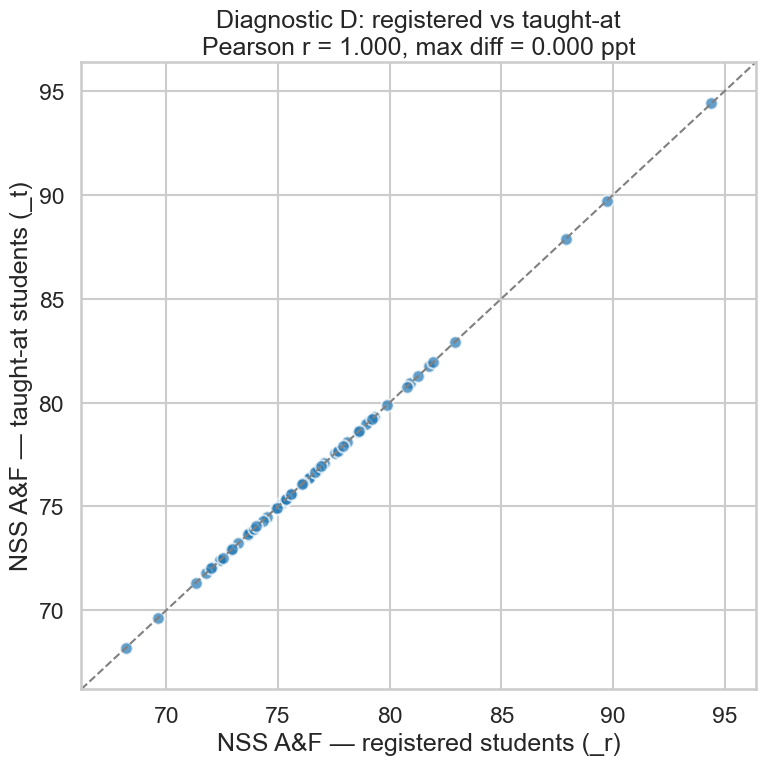

Registered and taught-at cuts are identical at Exeter (max diff = 0.000 ppt).


In [21]:
# Diagnostic D — registered (_r) vs taught-at (_t) NSS scores.
# At Exeter these are identical to within 0.000 ppt; the chart confirms that.
wide_t = pd.read_csv(PROCESSED / 'nss_exeter_taughtat_wide.csv')
rob = (
    merged_subject[['nss_subject', 'nss_year', TARGET]]
    .merge(wide_t[['subject', 'nss_year', TARGET]],
           left_on=['nss_subject', 'nss_year'],
           right_on=['subject', 'nss_year'],
           suffixes=('_r', '_t'))
    .dropna()
)
corr = rob[f'{TARGET}_r'].corr(rob[f'{TARGET}_t'])
max_diff = (rob[f'{TARGET}_r'] - rob[f'{TARGET}_t']).abs().max()

fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(rob[f'{TARGET}_r'], rob[f'{TARGET}_t'], s=80, alpha=0.7,
           color='#1f77b4', edgecolor='white')
lims = [min(rob[f'{TARGET}_r'].min(), rob[f'{TARGET}_t'].min()) - 2,
        max(rob[f'{TARGET}_r'].max(), rob[f'{TARGET}_t'].max()) + 2]
ax.plot(lims, lims, '--', color='gray', linewidth=1.5)
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel('NSS A&F — registered students (_r)')
ax.set_ylabel('NSS A&F — taught-at students (_t)')
ax.set_title(f'Diagnostic D: registered vs taught-at\nPearson r = {corr:.3f}, max diff = {max_diff:.3f} ppt')
plt.tight_layout()
plt.savefig(FIG_DIR / 'diag_d_robustness_r_vs_t.png', dpi=FIG_DPI, bbox_inches='tight')
plt.show()

print(f'Registered and taught-at cuts are identical at Exeter (max diff = {max_diff:.3f} ppt).')

## All files written by this notebook

**Blog charts (in `output2/figures/`):**
- `chart_1_assessment_mix.png`
- `chart_2_trends.png`
- `chart_3_feature_importance.png`
- `chart_4_pred_vs_actual.png`

**Diagnostics (in `output2/figures/`):**
- `diag_a_coursework_vs_satisfaction.png`
- `diag_b_nss_theme_heatmap.png`
- `diag_c_per_theme_importance.png`
- `diag_d_robustness_r_vs_t.png`

**Tables (in `data/processed2/`):**
- `blog_summary_table.csv` — one row per CAH2 subject for the latest NSS year, sorted by Assessment & Feedback positivity.